In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import warnings
warnings.filterwarnings('ignore')

In [54]:
df=pd.read_csv("online_retail_II.csv")

In [55]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [56]:
df.shape

(1067371, 8)

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [58]:
df.isna().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [59]:
df[df['Customer ID'].isna()].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.00,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.00,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.00,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.00,NaN,United Kingdom
577,489525,85226C,BLUE PULL BACK RACING CAR,1,2009-12-01 11:49:00,0.55,NaN,United Kingdom


In [60]:
df=df.dropna(subset=['Customer ID','Description'])

In [61]:
df[['Customer ID','Description']].isna().sum()

Customer ID    0
Description    0
dtype: int64

In [62]:
df.shape

(824364, 8)

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 824364 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      824364 non-null  object 
 1   StockCode    824364 non-null  object 
 2   Description  824364 non-null  object 
 3   Quantity     824364 non-null  int64  
 4   InvoiceDate  824364 non-null  object 
 5   Price        824364 non-null  float64
 6   Customer ID  824364 non-null  float64
 7   Country      824364 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 56.6+ MB


In [64]:
sum(df['Quantity']<=0)

18744

In [65]:
sum(df['Price']<=0)

71

In [66]:
df=df[(df['Quantity']>0) & (df['Price']>0)]

In [67]:
df.shape

(805549, 8)

In [68]:
sum(df['Quantity']<=0)

0

In [69]:
sum(df['Price']<=0)

0

In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 805549 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      805549 non-null  object 
 1   StockCode    805549 non-null  object 
 2   Description  805549 non-null  object 
 3   Quantity     805549 non-null  int64  
 4   InvoiceDate  805549 non-null  object 
 5   Price        805549 non-null  float64
 6   Customer ID  805549 non-null  float64
 7   Country      805549 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 55.3+ MB


In [71]:
df['InvoiceDate'].head()

0    2009-12-01 07:45:00
1    2009-12-01 07:45:00
2    2009-12-01 07:45:00
3    2009-12-01 07:45:00
4    2009-12-01 07:45:00
Name: InvoiceDate, dtype: object

In [72]:
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])
df['InvoiceDate'].dtype

dtype('<M8[ns]')

In [73]:
df['InvoiceDate']=df['InvoiceDate'].dt.date
df["InvoiceDate"]

0          2009-12-01
1          2009-12-01
2          2009-12-01
3          2009-12-01
4          2009-12-01
              ...    
1067366    2011-12-09
1067367    2011-12-09
1067368    2011-12-09
1067369    2011-12-09
1067370    2011-12-09
Name: InvoiceDate, Length: 805549, dtype: object

In [74]:
df['Analysis_Date']=df['InvoiceDate'].max()+pd.Timedelta(days=1)

In [75]:
df['Analysis_Date'].head()

0    2011-12-10
1    2011-12-10
2    2011-12-10
3    2011-12-10
4    2011-12-10
Name: Analysis_Date, dtype: object

In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 805549 entries, 0 to 1067370
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Invoice        805549 non-null  object 
 1   StockCode      805549 non-null  object 
 2   Description    805549 non-null  object 
 3   Quantity       805549 non-null  int64  
 4   InvoiceDate    805549 non-null  object 
 5   Price          805549 non-null  float64
 6   Customer ID    805549 non-null  float64
 7   Country        805549 non-null  object 
 8   Analysis_Date  805549 non-null  object 
dtypes: float64(2), int64(1), object(6)
memory usage: 61.5+ MB


In [77]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Analysis_Date'] = pd.to_datetime(df['Analysis_Date'])

In [78]:
df['Recency']=(df['Analysis_Date']-df['InvoiceDate']).dt.days
df['Recency'].head()

0    739
1    739
2    739
3    739
4    739
Name: Recency, dtype: int64

In [79]:
df['total_amount']=df['Quantity']*df['Price']
df['total_amount'].head()

0     83.4
1     81.0
2     81.0
3    100.8
4     30.0
Name: total_amount, dtype: float64

In [80]:
df=df.rename(columns={
    'Customer ID':'Customer_ID'
})
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer_ID', 'Country', 'Analysis_Date', 'Recency',
       'total_amount'],
      dtype='object')

In [81]:
df['Invoice'].nunique()

36969

In [82]:
df_customer_purchase_details=df.groupby('Customer_ID').agg(
    latest_date=('InvoiceDate','max'),
    frequency=('Invoice','nunique'),
    montery=('total_amount','sum')
).reset_index()

In [83]:
df_customer_purchase_details

,Customer_ID,latest_date,frequency,montery
0,12346.0,2011-01-18,12,77556.46
1,12347.0,2011-12-07,8,5633.32
2,12348.0,2011-09-25,5,2019.40
3,12349.0,2011-11-21,4,4428.69
4,12350.0,2011-02-02,1,334.40
...,...,...,...,...
5873,18283.0,2011-12-06,22,2736.65
5874,18284.0,2010-10-04,1,461.68
5875,18285.0,2010-02-17,1,427.00
5876,18286.0,2010-08-20,2,1296.43


In [84]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

analysis_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

df_customer_purchase_details = df.groupby('Customer_ID').agg(
    latest_date=('InvoiceDate', 'max'),
    frequency=('Invoice', 'nunique'),
    monetary=('total_amount', 'sum')
).reset_index()

df_customer_purchase_details['recency'] = (
    analysis_date - df_customer_purchase_details['latest_date']
).dt.days

In [85]:
df_customer_purchase_details.head(10)

,Customer_ID,latest_date,frequency,monetary,recency
0,12346.0,2011-01-18,12,77556.46,326
1,12347.0,2011-12-07,8,5633.32,3
2,12348.0,2011-09-25,5,2019.40,76
3,12349.0,2011-11-21,4,4428.69,19
4,12350.0,2011-02-02,1,334.40,311
5,12351.0,2010-11-29,1,300.93,376
6,12352.0,2011-11-03,10,2849.84,37
7,12353.0,2011-05-19,2,406.76,205
8,12354.0,2011-04-21,1,1079.40,233
9,12355.0,2011-05-09,2,947.61,215


In [86]:
df_customer_purchase_details.drop('latest_date',axis=1,inplace=True)

In [87]:
df_customer_purchase_details.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5878 entries, 0 to 5877
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Customer_ID  5878 non-null   float64
 1   frequency    5878 non-null   int64  
 2   monetary     5878 non-null   float64
 3   recency      5878 non-null   int64  
dtypes: float64(2), int64(2)
memory usage: 183.8 KB


In [88]:
df_customer_purchase_details.describe()

,Customer_ID,frequency,monetary,recency
count,5878.000000,5878.000000,5878.000000,5878.000000
mean,15315.313542,6.289384,3018.616737,201.866791
std,1715.572666,13.009406,14737.731040,209.353961
min,12346.000000,1.000000,2.950000,1.000000
25%,13833.250000,1.000000,348.762500,26.000000
50%,15314.500000,3.000000,898.915000,96.000000
75%,16797.750000,7.000000,2307.090000,380.000000
max,18287.000000,398.000000,608821.650000,739.000000


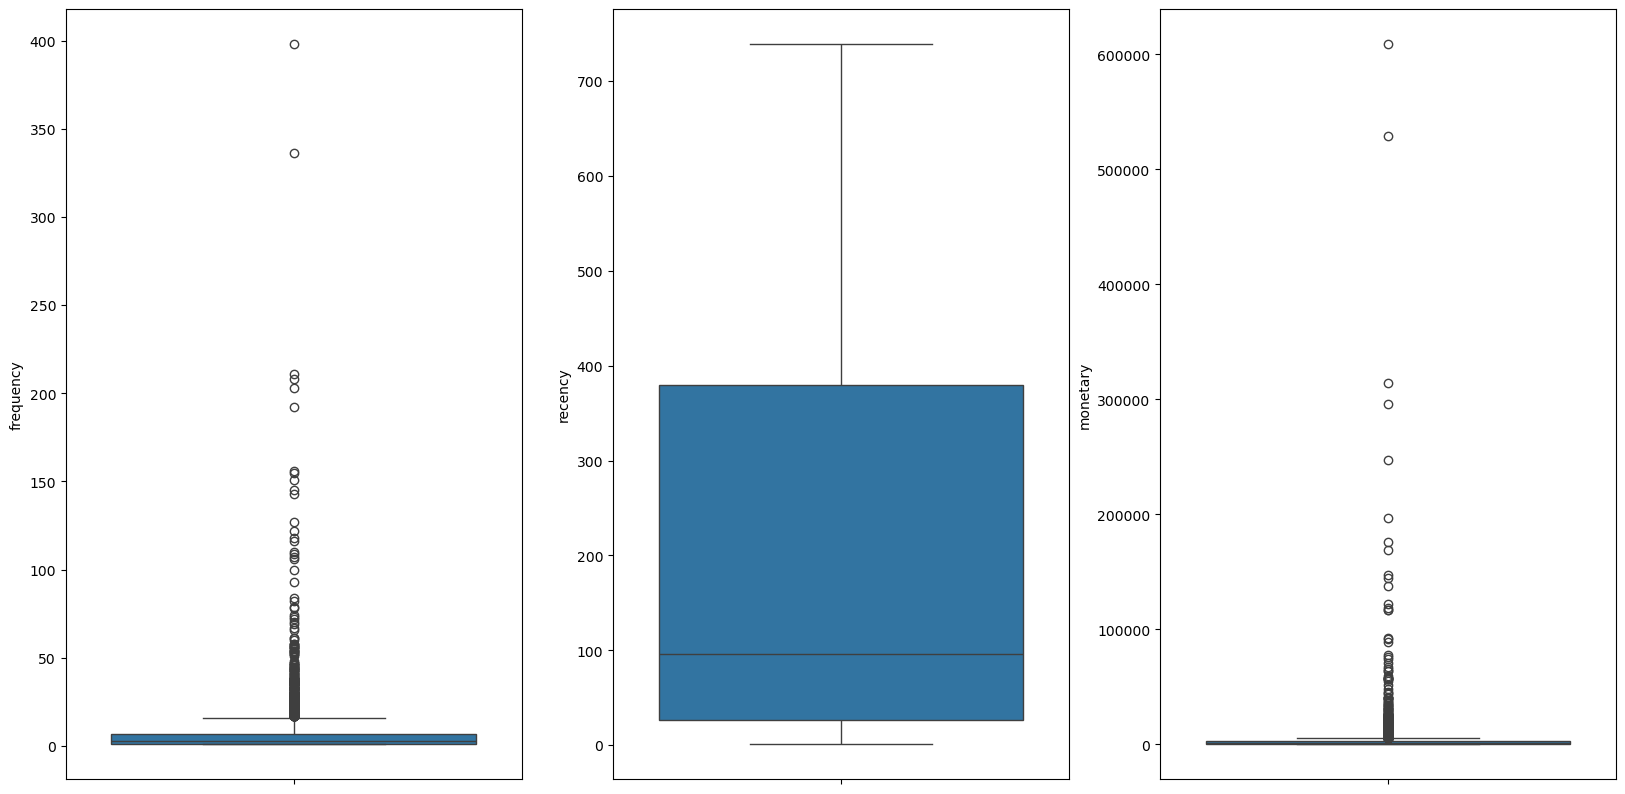

In [89]:
plt.figure(figsize=(20,10))
plt.subplot(1,3,1)
sns.boxplot(data=df_customer_purchase_details,y="frequency")
plt.subplot(1,3,2)
sns.boxplot(data=df_customer_purchase_details,y="recency")
plt.subplot(1,3,3)
sns.boxplot(data=df_customer_purchase_details,y="monetary")
plt.show()

In [90]:
X=df_customer_purchase_details[['recency','frequency','monetary']]
X.columns

Index(['recency', 'frequency', 'monetary'], dtype='object')

In [91]:
X_log=np.log1p(X)

In [92]:
from sklearn.preprocessing import RobustScaler

scaler=RobustScaler()
X_scaled=scaler.fit_transform(X_log)

X_scaled[:11]

array([[ 0.45911084,  0.85021986,  2.36177033],
       [-1.20455677,  0.5849625 ,  0.97212942],
       [-0.08723416,  0.29248125,  0.42860855],
       [-0.59652477,  0.16096405,  0.84464827],
       [ 0.44137089, -0.5       , -0.52306189],
       [ 0.51286492, -0.5       , -0.57877627],
       [-0.35403781,  0.72971581,  0.61108475],
       [ 0.28453942, -0.20751875, -0.41953084],
       [ 0.33268705, -0.5       ,  0.09687014],
       [ 0.30244759, -0.20751875,  0.02792774],
       [-0.52764523,  0.40367746,  1.0375574 ]])

In [93]:
cols_median_iqr=pd.DataFrame({
    'Columns':X.columns,
    'Median':scaler.center_,
    'IQR':scaler.scale_
})

cols_median_iqr

,Columns,Median,IQR
0,recency,4.574711,2.646963
1,frequency,1.386294,1.386294
2,monetary,6.802300,1.886921


In [94]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score,davies_bouldin_score,calinski_harabasz_score

inertia_values=[]
silhouette_score_values=[]

for i in range(2,11):
    model=KMeans(
        n_clusters=i,
        init='k-means++',
        n_init='auto',
        max_iter=300,
        tol=0.0001,
        random_state=94
    )
    
    labels=model.fit_predict(X_scaled)
    
    inertia_values.append(model.inertia_)
    silhouette_score_values.append(silhouette_score(X_scaled,labels))

In [95]:
k_inertia_silhoutte=pd.DataFrame({
    'K-Range':range(2,11),
    'Inertia':inertia_values,
    "Silhouette_Score":silhouette_score_values
})

k_inertia_silhoutte

,K-Range,Inertia,Silhouette_Score
0,2,3435.324646,0.438439
1,3,2496.785415,0.347329
2,4,1984.866797,0.359649
3,5,1638.432369,0.340519
4,6,1445.510920,0.301168
5,7,1275.658796,0.304038
6,8,1161.112727,0.299991
7,9,1076.963113,0.296093
8,10,992.526786,0.281254


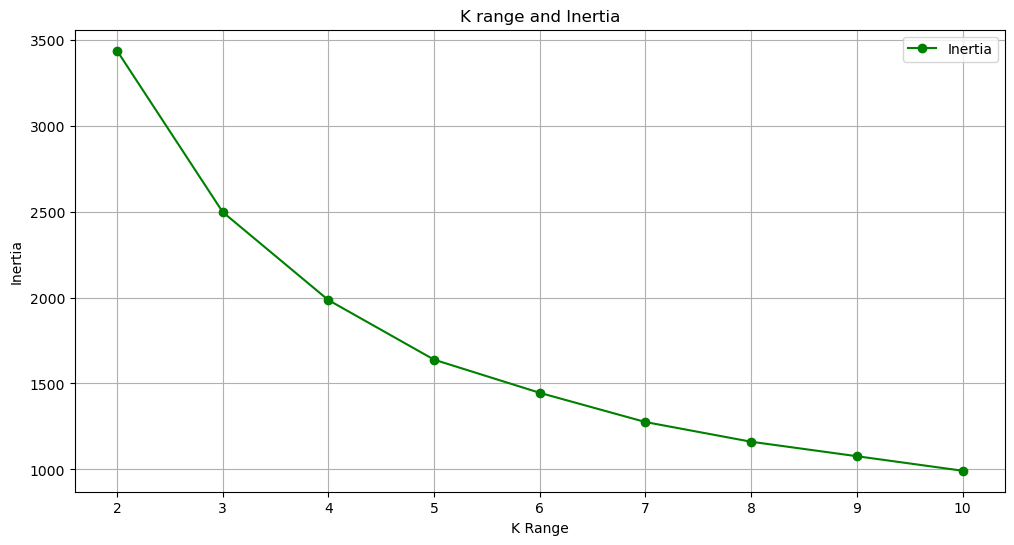

In [96]:
plt.figure(figsize=(12,6))

plt.plot(
    range(2,11),
    inertia_values,
    marker='o',
    linestyle='-',
    color='g',
    label='Inertia'
)

plt.title("K range and Inertia")
plt.xlabel("K Range")
plt.ylabel("Inertia")
plt.legend()

plt.grid(True)
plt.show()

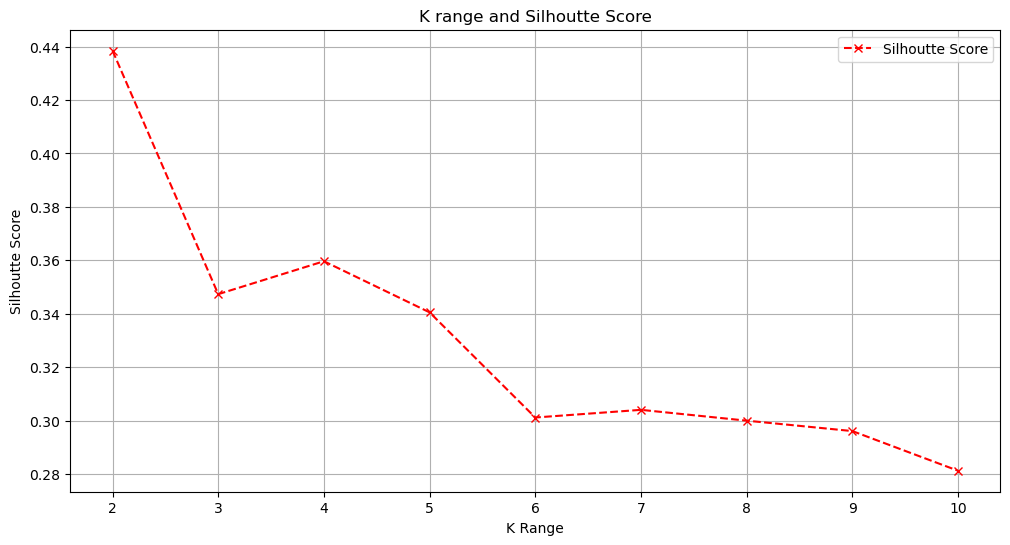

In [97]:
plt.figure(figsize=(12,6))

plt.plot(
    range(2,11),
    silhouette_score_values,
    marker='x',
    linestyle='--',
    color='r',
    label='Silhoutte Score'
)

plt.title("K range and Silhoutte Score")
plt.xlabel("K Range")
plt.ylabel("Silhoutte Score")
plt.legend()

plt.grid(True)
plt.show()

In [100]:
best_model=KMeans(
    n_clusters=4,
    init='k-means++',
    n_init='auto',
    max_iter=300,
    tol=0.0001,
    random_state=94
)

df_customer_purchase_details['Cluster']=best_model.fit_predict(X_scaled)
df_customer_purchase_details['Cluster'].value_counts()

Cluster
0    1896
2    1512
1    1244
3    1226
Name: count, dtype: int64

In [101]:
df_customer_purchase_details.groupby('Cluster')[['frequency', 'monetary', 'recency']].agg(['mean', 'median', 'min', 'max'])

frequency                      monetary                     \
              mean median min  max          mean    median      min   
Cluster                                                               
0         1.340190    1.0   1    8    278.057653   248.055     2.95   
1         3.401929    3.0   1   14    940.439367   807.145    77.40   
2         4.509259    4.0   1   20   1712.351341  1320.445   167.42   
3        19.068515   13.0   2  398  10976.549810  5126.800  1407.26   

                       recency                  
               max        mean median min  max  
Cluster                                         
0           966.66  383.593354  397.0  16  739  
1          3861.00   27.991961   24.0   1   97  
2         34095.26  253.560847  215.0  36  739  
3        608821.65   33.502447   18.0   1  577

In [102]:
df_customer_purchase_details

,Customer_ID,frequency,monetary,recency,Cluster
0,12346.0,12,77556.46,326,3
1,12347.0,8,5633.32,3,3
2,12348.0,5,2019.40,76,2
3,12349.0,4,4428.69,19,3
4,12350.0,1,334.40,311,0
...,...,...,...,...,...
5873,18283.0,22,2736.65,4,3
5874,18284.0,1,461.68,432,0
5875,18285.0,1,427.00,661,0
5876,18286.0,2,1296.43,477,2


In [104]:
df_customer_purchase_details["Segment"]=df_customer_purchase_details["Cluster"].map({
    0: "Inactive / Low-Value Customers",
    1: "Recent Regular Customers",
    2: "At-Risk Customers",
    3: "High-Value Loyal Customers"
})
df_customer_purchase_details.head(10)

,Customer_ID,frequency,monetary,recency,Cluster,Segment
0,12346.0,12,77556.46,326,3,High-Value Loyal Customers
1,12347.0,8,5633.32,3,3,High-Value Loyal Customers
2,12348.0,5,2019.40,76,2,At-Risk Customers
3,12349.0,4,4428.69,19,3,High-Value Loyal Customers
4,12350.0,1,334.40,311,0,Inactive / Low-Value Customers
5,12351.0,1,300.93,376,0,Inactive / Low-Value Customers
6,12352.0,10,2849.84,37,3,High-Value Loyal Customers
7,12353.0,2,406.76,205,0,Inactive / Low-Value Customers
8,12354.0,1,1079.40,233,2,At-Risk Customers
9,12355.0,2,947.61,215,2,At-Risk Customers


In [106]:
df_customer_purchase_details["Segment"].value_counts()

Segment
Inactive / Low-Value Customers    1896
At-Risk Customers                 1512
Recent Regular Customers          1244
High-Value Loyal Customers        1226
Name: count, dtype: int64

In [110]:
df_customer_segment=df_customer_purchase_details.groupby("Segment").agg(
    avg_recency=('recency','mean'),
    avg_frequency=('frequency','mean'),
    avg_monetary=('monetary','mean'),
    total_customers=('Customer_ID','nunique')
).reset_index()

In [111]:
df_customer_segment

,Segment,avg_recency,avg_frequency,avg_monetary,total_customers
0,At-Risk Customers,253.560847,4.509259,1712.351341,1512
1,High-Value Loyal Customers,33.502447,19.068515,10976.549810,1226
2,Inactive / Low-Value Customers,383.593354,1.340190,278.057653,1896
3,Recent Regular Customers,27.991961,3.401929,940.439367,1244


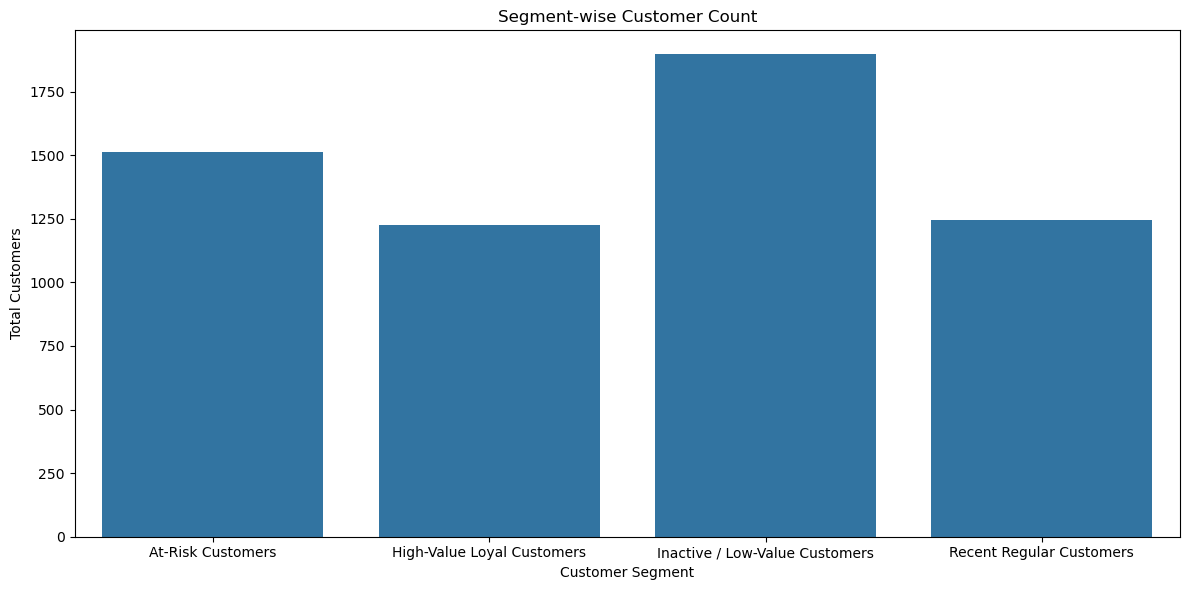

In [132]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=df_customer_segment,
    x="Segment",
    y="total_customers"
)

plt.title("Segment-wise Customer Count")
plt.xlabel("Customer Segment")
plt.ylabel("Total Customers")
plt.tight_layout()
plt.show()

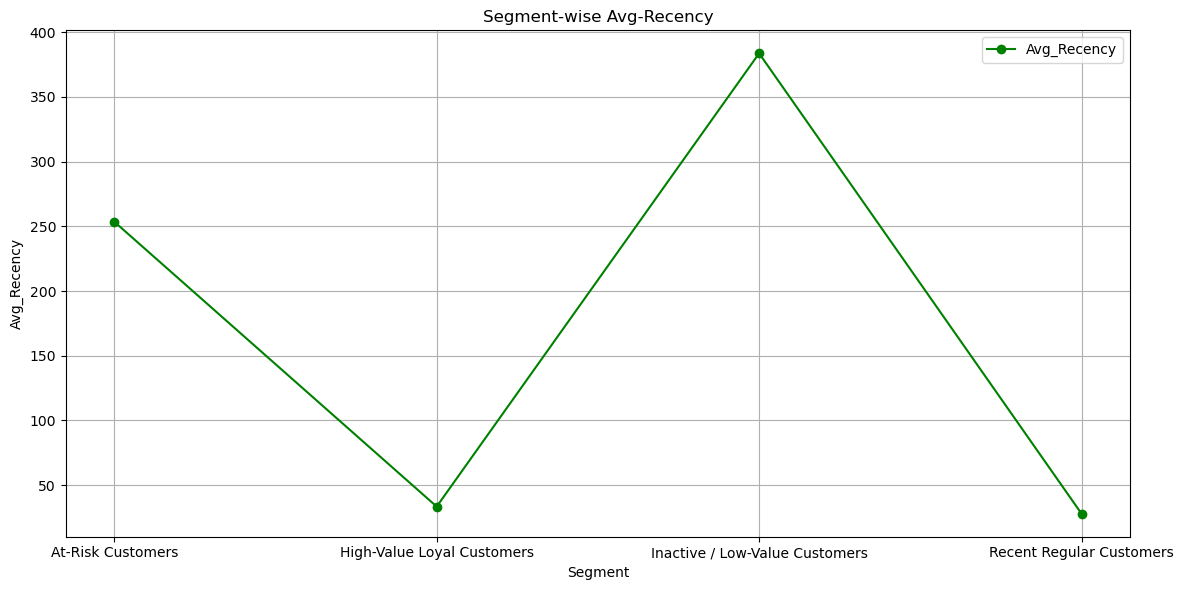

In [121]:
plt.figure(figsize=(12,6))

plt.plot(
    df_customer_segment["Segment"],
    df_customer_segment['avg_recency'],
    marker='o',
    linestyle='-',
    color='g',
    label="Avg_Recency"
)

plt.title("Segment-wise Avg-Recency")
plt.xlabel("Segment")
plt.ylabel("Avg_Recency")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

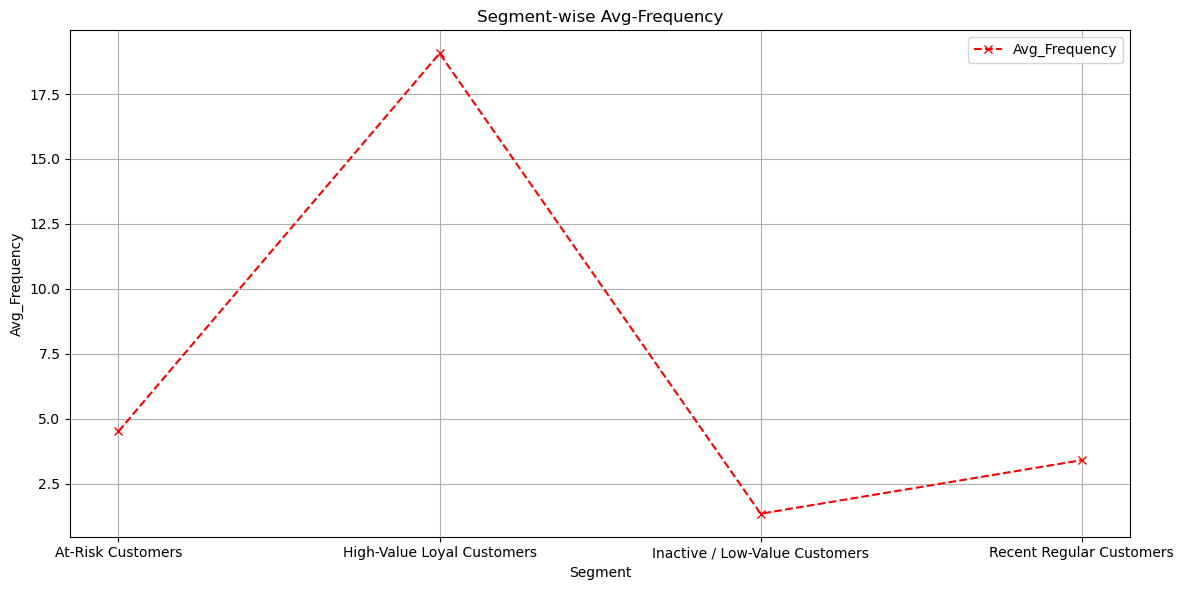

In [122]:
plt.figure(figsize=(12,6))

plt.plot(
    df_customer_segment["Segment"],
    df_customer_segment['avg_frequency'],
    marker='x',
    linestyle='--',
    color='r',
    label="Avg_Frequency"
)

plt.title("Segment-wise Avg-Frequency")
plt.xlabel("Segment")
plt.ylabel("Avg_Frequency")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

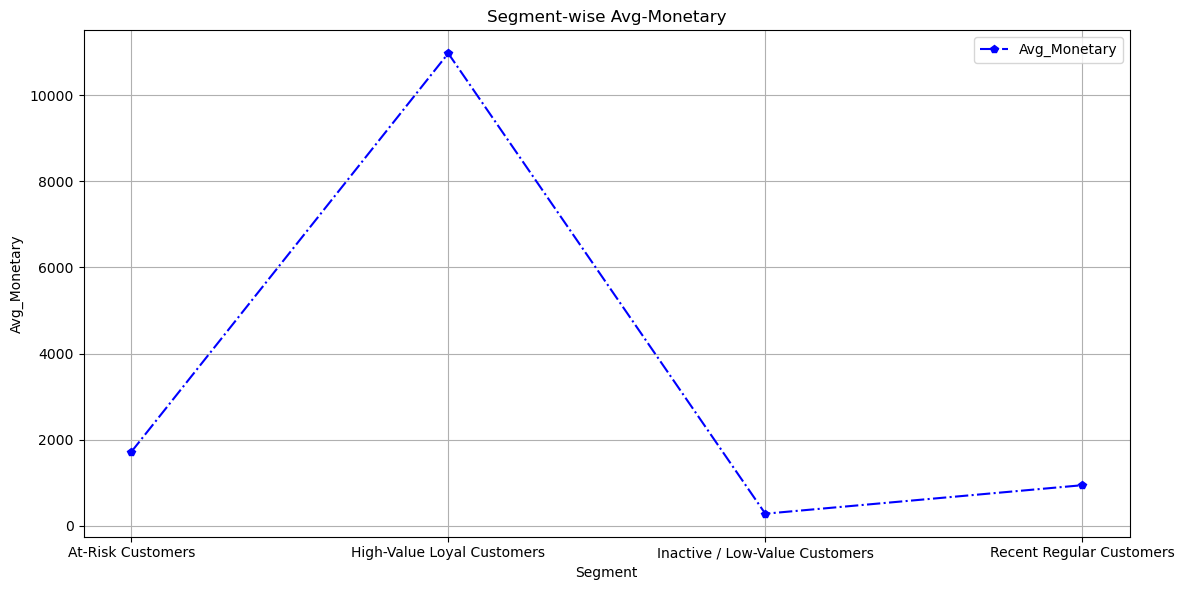

In [124]:
plt.figure(figsize=(12,6))

plt.plot(
    df_customer_segment["Segment"],
    df_customer_segment['avg_monetary'],
    marker='p',
    linestyle='-.',
    color='b',
    label="Avg_Monetary"
)

plt.title("Segment-wise Avg-Monetary")
plt.xlabel("Segment")
plt.ylabel("Avg_Monetary")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# **Insights**

## **Insight 1: Inactive / Low-Value Customers**

- Inactive / Low-Value Customers form the largest segment with 1896 customers. 
- They have the lowest average frequency and monetary value, and the highest average recency. 
- This means these customers purchased rarely, spent less, and have not purchased for a long time.

## Insight 2: High-Value Loyal Customers

- High-Value Loyal Customers have the highest average frequency and monetary value with low recency. 
- This means they purchase often, spend more, and are still active customers.

## Insight 3: At-Risk Customers

- At-Risk Customers have moderate frequency and monetary value, but high recency. 
- This means they were valuable in the past, but they have not purchased recently.

## Insight 4: Recent Regular Customers

- Recent Regular Customers have low recency and moderate purchase behavior. 
- This means they purchased recently and may become loyal customers if properly engaged.

# Business Recommendations

- Based on the customer segments created using RFM analysis and K-Means clustering, the following business strategies can be applied for each segment:

| Segment | Business Recommendation |
|---|---|
| Inactive / Low-Value Customers | Send reactivation offers, discounts, and reminder campaigns |
| At-Risk Customers | Send win-back campaigns and personalized offers |
| Recent Regular Customers | Encourage repeat purchases with product recommendations |
| High-Value Loyal Customers | Provide loyalty rewards, premium offers, and early access deals |

# ✅ Project Conclusion

In this project, **customer segmentation** was performed using **RFM analysis** and **K-Means Clustering**.

The customer behavior was analyzed using three important features:

- **Recency**: How recently a customer made a purchase
- **Frequency**: How often a customer made purchases
- **Monetary**: How much money a customer spent

After creating the RFM features, **log transformation** and **RobustScaler** were applied to reduce the impact of outliers and bring the features into a similar scale.

Using the Elbow Method and Silhouette Score, **K = 4** was selected as the final number of clusters. The K-Means model grouped customers into four meaningful segments:

| Segment | Description |
|---|---|
| **Inactive / Low-Value Customers** | Customers with low purchase frequency, low spending, and high recency |
| **At-Risk Customers** | Customers who purchased in the past but have not purchased recently |
| **Recent Regular Customers** | Customers who purchased recently and show moderate buying behavior |
| **High-Value Loyal Customers** | Customers who purchase frequently, spend more, and are recently active |

## Key Findings

- **Inactive / Low-Value Customers** formed the largest customer segment.
- **High-Value Loyal Customers** had the highest average frequency and monetary value.
- **At-Risk Customers** showed good past purchase behavior but had high recency.
- **Recent Regular Customers** showed recent activity and have potential to become loyal customers.

## Business Recommendations

- Provide **loyalty rewards and premium offers** to High-Value Loyal Customers.
- Send **win-back campaigns and personalized offers** to At-Risk Customers.
- Encourage Recent Regular Customers with **product recommendations and repeat purchase offers**.
- Use **discounts and reactivation campaigns** for Inactive / Low-Value Customers.

## Final Outcome

This project shows how unsupervised machine learning can be used to understand customer behavior.  
By segmenting customers into meaningful groups, businesses can create better marketing strategies, improve customer retention, and increase overall sales performance.

In [134]:
import joblib

joblib.dump(best_model,'model.pkl')
joblib.dump(scaler,'robust_scaler.pkl')

['robust_scaler.pkl']